<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h3 style="text-align: center;"><b>Домашнее задание. Детекция объектов</b></h3>

В этом домашнем задании мы продолжим работу над детектором из семинара, поэтому при необходимости можете заимствовать оттуда любой код.

Домашнее задание можно разделить на следующие части:

* Переделываем модель [4]
  * Backbone[1],
  * Neck [2],
  * Head [1]
* Label assignment [3]:
  * TAL [3]
* Лоссы [1]:
  * CIoU loss [1]
* Кто больше? [5]
  * 0.05 mAP [1]
  * 0.1 mAP  [2]
  * 0.2 mAP [5]

**Максимальный балл:** 10 баллов. (+3 балла бонус).

In [ ]:
import torch
import numpy as np
import pandas as pd
import albumentations as A

from PIL import Image
from torchvision import transforms
from torch.utils.data import Dataset
from albumentations.pytorch.transforms import ToTensorV2

import io

### Загрузка данных

Мы продолжаем работу с датасетом из семинара - Halo infinite ([сслыка](https://universe.roboflow.com/graham-doerksen/halo-infinite-angel-aim)). Загрузка данных и создание датасета полностью скопированы из семинара.

Сначала загружаем данные

In [ ]:
splits = {'train': 'data/train-00000-of-00001-0d6632d599c29801.parquet',
          'validation': 'data/validation-00000-of-00001-c6b77a557eeedd52.parquet',
          'test': 'data/test-00000-of-00001-866d29d8989ea915.parquet'}
df_train = pd.read_parquet("hf://datasets/Francesco/halo-infinite-angel-videogame/" + splits["train"])
# df_validation = pd.read_parquet("hf://datasets/Francesco/halo-infinite-angel-videogame/" + splits["validation"])
df_test = pd.read_parquet("hf://datasets/Francesco/halo-infinite-angel-videogame/" + splits["test"])

Создаем датасет для предобработки данных

In [ ]:
class HaloDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        df_objects = pd.json_normalize(dataframe['objects'])[["bbox", "category"]]
        df_images = pd.json_normalize(dataframe['image'])[["bytes"]]
        self.data = dataframe[["image_id"]].join(df_objects).join(df_images)
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        """Загружаем данные и разметку для объекта с индексом `idx`.

        labels: List[int] Набор классов для каждого ббокса,
        boxes: List[List[int]] Набор ббоксов в формате (x_min, y_min, x_max, y_max).
        """
        row = self.data.iloc[idx]
        image = Image.open(io.BytesIO(row["bytes"]))
        image = np.array(image)

        target = {}
        target["image_id"] = row["image_id"]

        labels = [row["category"]] if isinstance(row["category"], int) else row['category']
        # Вычитаем единицу чтобы классы начинались с нуля
        labels = [label for label in labels]

        # 1. Получаем боксы в формате COCO: [x_min, y_min, width, height]
        boxes_coco = row['bbox'].tolist()

        # 2. Конвертируем в Pascal VOC: [x_min, y_min, x_max, y_max]
        boxes_voc = []
        for box in boxes_coco:
            x_min, y_min, w, h = box[:4]
            x_max = x_min + w
            y_max = y_min + h
            boxes_voc.append([x_min, y_min, x_max, y_max])

        if self.transform is not None:
            # 3. Передаём боксы уже в формате Pascal VOC
            transformed = self.transform(image=image, bboxes=boxes_voc, labels=labels)
            image, boxes, labels = transformed["image"], transformed["bboxes"], transformed["labels"]
        else:
            image = transforms.ToTensor()(image)
            boxes = boxes_voc

        target['boxes'] = torch.tensor(np.array(boxes), dtype=torch.float32)
        target['labels'] = torch.tensor(labels, dtype=torch.int64)
        return image, target


def collate_fn(batch):
    batch = tuple(zip(*batch))
    images = torch.stack(batch[0])
    return images, batch[1]

Чтобы модель не переобучалась, можно добавить больше аугментаций, весь список можно посмотреть тут [[ссылка](https://explore.albumentations.ai/)].

Какие можно использовать аугментации?
* Добавить зум `RandomResizedCrop`,
* Сделать цветовые аугментации типа `RandomBrightnessContrast` и/или `HueSaturationValue`,
* Добавить шум `GaussNoise`,
* Вырезать случайные части изображения `CoarseDropout`,
* И любые другие!

Аугментации можно комбинировать посредствам `A.OneOf`, `A.SomeOf` или `A.RandomOrder`.

Хоть аугментации ограничиваются только вашей фантазией, перед обучением советуем посмотреть на результат преобразований и убедиться, что изображение ещё поддается детекции:)

In [ ]:
mean = (0.485, 0.456, 0.406)
std = (0.229, 0.224, 0.225)

train_transform = A.Compose(
    [
        # Добавляй сюда свои аугментации при необходимости!

        # Ресайз к фиксированному размеру
        A.Resize(height=640, width=640, p=1.0),

        # --- Геометрические ---

        A.HorizontalFlip(p=0.5), # Зеркальное отражение (персонажи/оружие симметричны)
        # A.RandomScale(scale_limit=0.2, p=0.5),
        # A.ShiftScaleRotate(
        #     shift_limit=0.1,
        #     scale_limit=0.15,  # Чуть увеличили, чтобы покрыть и RandomScale
        #     rotate_limit=15,
        #     p=0.5,
        #     border_mode=0,     # 0 = cv2.BORDER_CONSTANT (заполнение черным)
        #     value=0            # Черные поля (как в игре при обрезке)
        # ),

        # --- Цветовые (важно для разных настроек игры) ---

        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.8),
        A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=20, p=0.7),
        A.RGBShift(r_shift_limit=15, g_shift_limit=15, b_shift_limit=15, p=0.5),

        # --- Качество изображения (эмуляция сжатия/стриминга) ---

        A.ImageCompression(quality_lower=70, quality_upper=100, p=0.5),
        A.GaussianBlur(blur_limit=(3, 7), p=0.3),  # Motion blur в игре
        A.GaussNoise(var_limit=(10.0, 50.0), p=0.4),


        # ФИНАЛЬНЫЙ Resize (перед нормализацией!)
        A.Resize(height=640, width=640, p=1.0),

        # --- Остальное ---
        A.Normalize(mean=mean, std=std),
        ToTensorV2(),
    ],
    # Раскомментируй, если аугментации изменяют ббоксы.
    # Не забудь указать верный формат для ббоксов.
    bbox_params=A.BboxParams(
        format='pascal_voc',          # Альтернатива - format='coco'
        label_fields=['labels'],
        min_visibility=0.1,     # Удалять боксы, если видно менее 10% объекта
        min_area=20            # Удалять слишком мелкие боксы (шум)
    )
)

test_transform = A.Compose(
    [
        # Ресайз к фиксированному размеру
        A.Resize(height=640, width=640, p=1.0),
        A.Normalize(mean=mean, std=std),
        ToTensorV2(),
    ]
)

/tmp/ipykernel_575/552713608.py:32: UserWarning: Argument(s) 'quality_lower, quality_upper' are not valid for transform ImageCompression
  A.ImageCompression(quality_lower=70, quality_upper=100, p=0.5),
/tmp/ipykernel_575/552713608.py:34: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 50.0), p=0.4),


Не забываем инициализировать наш датасет

In [ ]:
train_dataset = HaloDataset(df_train, transform=train_transform)
# val_dataset = HaloDataset(df_validation, transform=test_transform)
test_dataset = HaloDataset(df_test, transform=test_transform)

In [ ]:
# После загрузки train_dataset
all_labels = []
for i in range(len(train_dataset)):
    _, target = train_dataset[i]
    all_labels.extend(target['labels'].tolist())
print("Unique labels in dataset:", set(all_labels))
print("Number of classes (excluding background):", len(set(all_labels)))

Unique labels in dataset: {1, 2, 3, 4}
Number of classes (excluding background): 4


## Переделываем модель [4 балла]

В семинаре мы реализовали самый базовый детектор, а сейчас настало время его улучшать.

### Backbone [1 балл]

Хорошей практикой считается размораживать несколько последних слоев в backbone, это позволяет немного улучить качество модели. Давайте улушчим класс Backbone из лекции, добавив ему возможность разморозки __k__ последних слоев или блоков (на ваш выбор).

In [ ]:
import torch
import torch.nn as nn
import timm

class Backbone(nn.Module):
    def __init__(self, model_name="efficientnet_b1", out_indices=(2, 3, 4), unfreeze_last=1):
        super().__init__()

        # 1. Создание модели
        self.backbone = timm.create_model(
            model_name,
            pretrained=True,
            features_only=True,  # Возвращает список фичей
            # out_indices=out_indices  # ⚠️ В timm это может не сработать напрямую
        )

        # 2. Замораживаем ВСЕ параметры
        for param in self.backbone.parameters():
            param.requires_grad = False

        # 3. Размораживаем последние K блоков (слоёв)
        self._unfreeze_last_layers(unfreeze_last)

        # 4. Сохраняем каналы (фильтруем по out_indices)
        all_channels = self.backbone.feature_info.channels()
        self._out_channels = [all_channels[i] for i in out_indices]
        self.out_indices = out_indices

        # YOUR CODE HERE!

    def _unfreeze_last_layers(self, k):
        """Корректная разморозка последних k модулей с параметрами"""
        if k <= 0:
            print("unfreeze_last=0, все слои заморожены")
            return

        named_modules = list(self.backbone.named_modules())
        modules_with_params = [
            (name, module) for name, module in named_modules
            if len(list(module.parameters())) > 0
        ]

        # Берём последние k модулей
        unfrozen_names = []
        for name, module in modules_with_params[-k:]:
            for param in module.parameters():
                param.requires_grad = True
            unfrozen_names.append(name)

        print(f"✅ Unfrozen last {k} layers:")
        for name in unfrozen_names:
            print(f"   - {name}")

    @property
    def out_channels(self):
        """Возвращает количество каналов для каждого уровня (нужно для FPN/Head)"""
        return self._out_channels

    def forward(self, x):
        features = self.backbone(x)
        # Возвращаем только нужные индексы (если out_indices не сработал в create_model)
        return tuple(features[i] for i in self.out_indices)
        # YOUR CODE HERE!

### NECK [2 балла]

Следующее улучшение коснется шеи. Предлагаем реализовать знакомую из лекции архитектуру FPN.

#### Feature Pyramid Network

<center><img src="https://user-images.githubusercontent.com/57972646/69858594-b14a6c00-12d5-11ea-8c3e-3c17063110d3.png"/></center>


* [Feature Pyramid Networks for Object Detection](https://arxiv.org/abs/1612.03144)

Она состоит из top-down пути, в котором происходит 2 вещи:
1. Увеличивается пространственная размерность фичей,
2. С помощью скипконнекшеннов, добавляются фичи из backbone модели.

Для увеличения пространственной размерности используется __nearest neighbor upsampling__, а фичи из шеи и бекбоуна суммируются.

__TIPS__:
* Можете использовать базовые классы из лекции,
* Воспользуйтесь AnchorGenerator-ом, чтобы создавать якоря сразу для нескольких выходов,
* Не забудьте использовать nn.ModuleList, если захотите сделать динамическое количество голов у модели,
* Также, можно добавить доп конволюцию (3х3 с паддингом) у каждого выхода шеи.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models.detection.anchor_utils import AnchorGenerator

class FPN(nn.Module): # class neck
    def __init__(self, in_channels_list, out_channels=256):
        """
        Feature Pyramid Network для детекции объектов.

        Args:
            in_channels_list: Список каналов от Backbone (напр. [40, 112, 320])
            out_channels: Количество каналов на выходе каждого уровня FPN (стандарт 256)
        """
        super().__init__()
        self.out_channels = out_channels

        # 1. Lateral Convolutions (1x1) - выравнивание каналов
        # Используем ModuleList для динамического количества уровней
        self.lateral_convs = nn.ModuleList()
        for in_channels in in_channels_list:
            self.lateral_convs.append(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
            )

        # 2. Output Convolutions (3x3) - сглаживание артефактов
        # Добавляем паддинг=1, чтобы сохранить размерность
        self.output_convs = nn.ModuleList()
        for _ in in_channels_list:
            self.output_convs.append(
                nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False)
            )

        # Инициализация весов
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')

    def forward(self, features):
        """
        Top-Down pathway с skip connections.

        Args:
            features: Кортеж тензоров от Backbone [(B, C2, H2, W2), (B, C3, H3, W3), ...]
                      От меньшего разрешения к большему (или наоборот - проверим порядок)
        Returns:
            Кортеж тензоров FPN [(B, 256, H2, W2), (B, 256, H3, W3), ...]
        """
        # Шаг 1: Lateral connections (выравнивание каналов через 1x1 conv)
        lateral_features = []
        for i, feature in enumerate(features):
            lateral_features.append(self.lateral_convs[i](feature))

        # Шаг 2: Top-Down pathway (начинаем с самого глубокого слоя - последний в списке)
        results = []

        # Самый глубокий слой (P5) - база, ничего не апсемплим сверху
        prev_feature = lateral_features[-1]
        results.append(prev_feature)

        # Идем от глубокого к мелкому (справа налево)
        for i in range(len(lateral_features) - 2, -1, -1):
            # 1. Увеличиваем пространственную размерность (nearest neighbor upsampling)
            upsampled = F.interpolate(
                prev_feature,
                scale_factor=2,
                mode='nearest'  # Как в задании
            )

            # 2. Skip connection: добавляем фичи из backbone (element-wise sum)
            current = lateral_features[i] + upsampled

            results.append(current)
            prev_feature = current

        # Результаты сейчас в порядке [P5, P4, P3...], разворачиваем в [P3, P4, P5...]
        results = results[::-1]

        # Шаг 3: Output convolutions (3x3 с паддингом для каждого выхода)
        final_features = []
        for i, feature in enumerate(results):
            final_features.append(self.output_convs[i](feature))

        return tuple(final_features)

AnchorGenerator:

In [ ]:
import torch
import torch.nn as nn

class AnchorGenerator(nn.Module):
    def __init__(self, sizes=((32,), (64,), (128,)),
                 aspect_ratios=((0.5, 1.0, 2.0),) * 3,
                 strides=(8, 16, 32)):  # 🆕 Добавлен strides
        """
        Args:
            sizes: Размеры якорей для каждого уровня FPN
            aspect_ratios: Соотношения сторон для каждого уровня
            strides: 🆕 Шаг для каждого уровня FPN (8, 16, 32)
        """
        super().__init__()
        self.sizes = sizes
        self.aspect_ratios = aspect_ratios
        self.strides = strides  # 🆕 Сохраняем strides

    def forward(self, feature_maps):
        all_anchors = []

        for i, feature_map in enumerate(feature_maps):
            B, C, H, W = feature_map.shape

            sizes = self.sizes[i]
            aspect_ratios = self.aspect_ratios[i]
            stride = self.strides[i]  # 🆕 Получаем stride для уровня

            anchors = self._generate_anchors(H, W, sizes, aspect_ratios, stride)  # 🆕 Передаём stride
            all_anchors.append(anchors)

        return all_anchors

    def _generate_anchors(self, H, W, sizes, aspect_ratios, stride):  # 🆕 Добавлен stride
        """Генерация якорей для одной карты признаков"""
        anchors = []

        for y in range(H):
            for x in range(W):
                # 🆕 Используем правильный stride
                cx = (x + 0.5) * stride  # 8, 16 или 32
                cy = (y + 0.5) * stride

                for size in sizes:
                    for aspect_ratio in aspect_ratios:
                        w = size * (aspect_ratio ** 0.5)
                        h = size / (aspect_ratio ** 0.5)
                        anchors.append([cx, cy, w, h])

        if len(anchors) > 0:
            return torch.tensor(anchors, dtype=torch.float32)
        else:
            return torch.empty((0, 4))

### Head [1 балл]

В качестве шеи можно выбрать __один из двух__ вариантов:

#### 1. Decoupled Head

Реализовать Decoupled Head из [YOLOX](https://arxiv.org/abs/2107.08430).
<center><img src="https://i.ibb.co/BVtBR2R3/Decoupled-head.jpg"/></center>

**TIP**: Возьмите за основу голову из семинара, тк она сильно похожа на Decoupled Head.

Изменять количество параметров у шей на разных уровнях не обязательно.

#### 2. Confidence score free head

Нужно взять за основу голову из семинара и полностью убрать предсказание confidence score. Чтобы модель предсказывала только 2 группы: ббоксы и классы.

Есть следующие способы удаления confidence score:
* Добавление нового класса ФОН. Обычно его обозначают нулевым классом.
* Присваивание ббоксам БЕЗ объекта вектор из нулей в качестве таргета.

Выберете тот, который вам больше нравится и будте внимательны при расчете лосса!

**Важно!** Удаление confidence score повлияет на следующие методы из семинара:
* target_assign
* ComputeLoss
* _filter_predictions

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Head(nn.Module):
    """
    Confidence Score Free Head.

    В отличие от классической головы:
    - НЕТ отдельного confidence score
    - Класс 0 = ФОН (background)
    - Классы 1..N = объекты

    Предсказания:
    - cls: [B, num_anchors * num_classes, H, W]
    - reg: [B, num_anchors * 4, H, W]  ← Только 4 координаты (без confidence!)
    """
    def __init__(self, in_channels, num_anchors, num_classes):
        """
        Args:
            in_channels: Количество каналов от FPN (256)
            num_anchors: Количество якорей на ячейку (3)
            num_classes: Количество классов ОБЪЕКТОВ (без фона!)
                         Внутри будет добавлен класс 0 = фон
        """
        super().__init__()
        self.num_anchors = num_anchors
        self.num_classes = num_classes  # Без фона
        self.num_classes_with_bg = num_classes + 1  # С фоном (класс 0)

        # Общая свёртка для обработки признаков
        self.conv = nn.Conv2d(in_channels, in_channels, kernel_size=3, padding=1)

        # Classification head: предсказываем классы + фон
        # Выход: num_anchors * (num_classes + 1)
        self.cls_head = nn.Conv2d(
            in_channels,
            num_anchors * self.num_classes_with_bg,
            kernel_size=1
        )

        # Regression head: только 4 координаты (dx, dy, dw, dh)
        # Выход: num_anchors * 4 (НЕТ confidence!)
        self.reg_head = nn.Conv2d(
            in_channels,
            num_anchors * 4,
            kernel_size=1
        )

        # Инициализация весов
        self._init_weights()

    def _init_weights(self):
        """Инициализация весов для стабильного обучения"""
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.normal_(m.weight, std=0.01)
                nn.init.constant_(m.bias, 0)

        # Особая инициализация для cls_head (важно для фона!)
        nn.init.constant_(self.cls_head.bias, 0)  # Смещение к фону на старте

    def forward(self, x):
        """
        Args:
            x: Тензор от FPN [B, 256, H, W]
        Returns:
            cls_logits: [B, num_anchors * num_classes_with_bg, H, W]
            bbox_preds: [B, num_anchors * 4, H, W]
        """
        # Общая обработка
        x = F.relu(self.conv(x))

        # Предсказания
        cls_logits = self.cls_head(x)
        bbox_preds = self.reg_head(x)

        return cls_logits, bbox_preds

Теперь можно снова реализовать класс детектора с учетом всех частей выше!

In [ ]:
class Detector(nn.Module):
    def __init__(self, num_classes=10, backbone_name="efficientnet_b1", unfreeze_last=10):
        super().__init__()

        # 1. Backbone
        self.backbone = Backbone(
            model_name=backbone_name,
            out_indices=(2, 3, 4),
            unfreeze_last=unfreeze_last
        )

        # 2. FPN Neck
        self.fpn = FPN(
            in_channels_list=self.backbone.out_channels,
            out_channels=256
        )

        # 3. Anchor Generator
        self.anchor_generator = AnchorGenerator(
            sizes=((64,), (128,), (256,)),
            aspect_ratios=((0.5, 1.0, 2.0),) * 3,
            strides=(8, 16, 32)  # 🆕 Правильные strides для P3, P4, P5
        )

        # 4. Head для каждого уровня FPN (nn.ModuleList!)
        self.num_levels = len(self.backbone.out_channels)
        self.heads = nn.ModuleList([
            Head(
                in_channels=256,
                num_anchors=3,
                num_classes=num_classes  # Без фона!
            ) for _ in range(self.num_levels)
        ])

        # Сохраняем количество классов с фоном для лосса
        self.num_classes_with_bg = num_classes + 1

    def forward(self, x):
        B = x.shape[0]  # Получаем размер батча

        # 1. Backbone → FPN
        features = self.backbone(x)
        fpn_features = self.fpn(features)

        # 2. Head → Предсказания
        all_cls_logits = []
        all_bbox_preds = []

        for i, feature_map in enumerate(fpn_features):
            cls_logits, bbox_preds = self.heads[i](feature_map)
            _, _, H, W = cls_logits.shape
            cls_logits = cls_logits.permute(0, 2, 3, 1).contiguous().view(B, -1, self.num_classes_with_bg)
            bbox_preds = bbox_preds.permute(0, 2, 3, 1).contiguous().view(B, -1, 4)
            all_cls_logits.append(cls_logits)
            all_bbox_preds.append(bbox_preds)

        cls_logits = torch.cat(all_cls_logits, dim=1)
        bbox_preds = torch.cat(all_bbox_preds, dim=1)

        # 3. Генерируем якоря
        anchors = self.anchor_generator(fpn_features)
        anchors = torch.cat(anchors, dim=0).to(x.device)  # [N_anchors, 4]

        # Добавляем размерность батча
        anchors = anchors.unsqueeze(0).expand(B, -1, -1)  # [B, N_anchors, 4]

        return {
            'cls_logits': cls_logits,
            'bbox_preds': bbox_preds,
            'anchors': anchors  # [B, N_anchors, 4]
        }
    # YOUR CODE HERE

## Label assignment [3 балла]
В этой секции предлагается заменить функцию `assign_target` на более современный алгоритм который называется Task alignment learning.

Он описан в статье [TOOD](https://arxiv.org/abs/2108.07755) в секции 3.2. Для удобства вот его основные шаги:

1. Посчитать значение метрики для каждого предсказанного ббокса:
    
$$t = s^\alpha * u^\beta$$
    
где,
* $s$ — classification score, или вероятность принадлежности предсказанного ббокса к классу реального ббокса (**GT**);
* $u$ — IoU между предсказанным и реальным ббоксами;
* $\alpha,\ \beta$ — нормализационные константы, обычно $\alpha = 6.0, \ \beta = 1.0$.
    
2. Отфильтровать предсказания на основе **GT**.

    Для якорных детекторов, обычно, выбираются только те предсказания, центры якорей которых находятся внутри GT.
4. Для каждого **GT** выбрать несколько (обычно 5 или 13) самых подходящих предсказаний.
5. Если предсказание рассматривается в качестве подходящего для нескольких **GT** — выбрать **GT** с наибольшим пересечением по IoU.


**BAЖНО**: если будете использовать Runner из лекции, не забудьте поменять параметры  в `self.assign_target_method` в методе `_run_train_epoch`.

In [ ]:
import torch
import torch.nn.functional as F

def _compute_iou_batch(boxes1, boxes2):
    """Вычисляет IoU между двумя наборами боксов (N,4) и (M,4)"""
    device = boxes1.device
    boxes1 = boxes1.to(device)
    boxes2 = boxes2.to(device)
    lt = torch.max(boxes1[:, None, :2], boxes2[None, :, :2])
    rb = torch.min(boxes1[:, None, 2:], boxes2[None, :, 2:])
    wh = (rb - lt).clamp(min=0)
    intersection = wh[:, :, 0] * wh[:, :, 1]
    area1 = (boxes1[:, 2] - boxes1[:, 0]) * (boxes1[:, 3] - boxes1[:, 1])
    area2 = (boxes2[:, 2] - boxes2[:, 0]) * (boxes2[:, 3] - boxes2[:, 1])
    union = area1[:, None] + area2[None, :] - intersection
    iou = intersection / union.clamp(min=1e-6)
    return iou

def TAL_assigner(cls_logits, bbox_preds, anchors, gt_boxes, gt_labels,
                 topk=13, alpha=6.0, beta=1.0, use_anchor_iou_fallback=True):
    """
    Task Alignment Learning Assigner — назначение позитивных сэмплов.
    """
    B, N_anchors, num_classes_with_bg = cls_logits.shape
    device = cls_logits.device

    assigned_gt_index = torch.full((B, N_anchors), -1, dtype=torch.long, device=device)
    assigned_labels = torch.zeros((B, N_anchors), dtype=torch.long, device=device)
    alignment_metrics = torch.zeros((B, N_anchors), dtype=torch.float32, device=device)

    if anchors.dim() == 2:
        anchors_expanded = anchors.unsqueeze(0).expand(B, -1, -1)
    else:
        anchors_expanded = anchors

    # Декодируем предсказанные боксы
    dx = bbox_preds[:, :, 0]
    dy = bbox_preds[:, :, 1]
    dw = bbox_preds[:, :, 2]
    dh = bbox_preds[:, :, 3]

    pred_cx = dx * anchors_expanded[:, :, 2] + anchors_expanded[:, :, 0]
    pred_cy = dy * anchors_expanded[:, :, 3] + anchors_expanded[:, :, 1]
    pred_w = torch.exp(dw) * anchors_expanded[:, :, 2]
    pred_h = torch.exp(dh) * anchors_expanded[:, :, 3]

    decoded_boxes = torch.stack([pred_cx, pred_cy, pred_w, pred_h], dim=-1)
    anchor_centers = anchors_expanded[:, :, :2].clone()

    for b in range(B):
        gt_b = gt_boxes[b]
        labels_b = gt_labels[b]          # 1..4
        if len(gt_b) == 0:
            continue

        M = len(gt_b)

        # Преобразуем предсказанные боксы в xyxy
        pred_xyxy = torch.zeros_like(decoded_boxes[b])
        pred_xyxy[:, 0] = decoded_boxes[b, :, 0] - decoded_boxes[b, :, 2] / 2
        pred_xyxy[:, 1] = decoded_boxes[b, :, 1] - decoded_boxes[b, :, 3] / 2
        pred_xyxy[:, 2] = decoded_boxes[b, :, 0] + decoded_boxes[b, :, 2] / 2
        pred_xyxy[:, 3] = decoded_boxes[b, :, 1] + decoded_boxes[b, :, 3] / 2

        iou_matrix = _compute_iou_batch(pred_xyxy, gt_b)

        cls_probs = F.softmax(cls_logits[b], dim=-1)
        s = cls_probs[:, labels_b]        # индексы 1..4
        t = (s ** alpha) * (iou_matrix ** beta)

        cx = anchor_centers[b, :, 0]
        cy = anchor_centers[b, :, 1]
        margin_x = (gt_b[:, 2] - gt_b[:, 0]) * 0.25
        margin_y = (gt_b[:, 3] - gt_b[:, 1]) * 0.25

        inside_mask = (cx[:, None] >= gt_b[:, 0] - margin_x) & \
                      (cx[:, None] <= gt_b[:, 2] + margin_x) & \
                      (cy[:, None] >= gt_b[:, 1] - margin_y) & \
                      (cy[:, None] <= gt_b[:, 3] + margin_y)

        t_filtered = t * inside_mask.float()

        k = min(topk, N_anchors)
        topk_metrics, topk_indices = torch.topk(t_filtered, k=k, dim=0)

        selected_mask = torch.zeros_like(t_filtered, dtype=torch.bool)
        selected_mask.scatter_(0, topk_indices, True)

        iou_for_selected = iou_matrix * selected_mask.float()
        max_iou_for_anchor, best_gt_for_anchor = iou_for_selected.max(dim=1)

        anchor_was_selected = selected_mask.any(dim=1)
        valid_anchor_mask = anchor_was_selected & (max_iou_for_anchor > 0)

        if valid_anchor_mask.sum() > 0:
            safe_indices = best_gt_for_anchor[valid_anchor_mask]
            safe_indices = torch.clamp(safe_indices, 0, M - 1)
            assigned_gt_index[b, valid_anchor_mask] = safe_indices
            assigned_labels[b, valid_anchor_mask] = labels_b[safe_indices]
            alignment_metrics[b, valid_anchor_mask] = t_filtered[valid_anchor_mask, safe_indices]

        # Fallback, если не нашлось положительных
        if use_anchor_iou_fallback and valid_anchor_mask.sum() == 0:
            anchor_boxes_xyxy = torch.zeros_like(anchors_expanded[b])
            anchor_boxes_xyxy[:, 0] = anchors_expanded[b, :, 0] - anchors_expanded[b, :, 2] / 2
            anchor_boxes_xyxy[:, 1] = anchors_expanded[b, :, 1] - anchors_expanded[b, :, 3] / 2
            anchor_boxes_xyxy[:, 2] = anchors_expanded[b, :, 0] + anchors_expanded[b, :, 2] / 2
            anchor_boxes_xyxy[:, 3] = anchors_expanded[b, :, 1] + anchors_expanded[b, :, 3] / 2

            iou_matrix_anchor = _compute_iou_batch(anchor_boxes_xyxy, gt_b)
            max_iou, best_gt = iou_matrix_anchor.max(dim=1)
            pos_mask = max_iou > 0.3
            if pos_mask.sum() > 0:
                safe_indices = best_gt[pos_mask]
                safe_indices = torch.clamp(safe_indices, 0, M - 1)
                assigned_gt_index[b, pos_mask] = safe_indices
                assigned_labels[b, pos_mask] = labels_b[safe_indices]
                alignment_metrics[b, pos_mask] = max_iou[pos_mask]

        # # Отладка для первого батча
        # if b == 0:
        #     print(f"  assigned_labels range: min={assigned_labels.min()}, max={assigned_labels.max()}, num_classes={num_classes_with_bg}")

    return assigned_gt_index, assigned_labels, alignment_metrics

### DIoU [1]

Вместо SmoothL1, который используется в семинаре, реализуем лосс, основанный на пересечении ббоксов. В качестве тренировки давайте напишем Distance Intersection over Union (DIoU).

<center><img src=https://wikidocs.net/images/page/163613/Free_Fig_5.png></center>

Для его реализации разобъем задачу на части:

**1. Реализуем IoU:**

Пусть даны координаты для предсказанного ($B^p$) и истинного ($B^g$) ббоксов в формате XYXY или VOC PASCAL (левый верхний и правый нижний углы):

$B^p=(x^p_1, y^p_1, x^p_2, y^p_2)$, $B^g=(x^g_1, y^g_1, x^g_2, y^g_2)$, тогда алгоритм расчета будет следующий:

    1. Найдем площади обоих ббоксов:
$$ A^p = (x^p_2 - x^p_1) * (y^p_2 - y^p_1) $$
$$ A^g = (x^g_2 - x^g_1) * (y^g_2 - y^g_1) $$

    2. Посчитаем пересечение между ббоксами:

Тут мы предлагаем вам подумать как в общем виде можно расчитать размеры ббокса, который будет являться пересечением $B^p$ и $B^g$, а затем посчитать его площадь:

$$x^I_1 = max(x₁ᵖ, x₁ᵍ) \qquad \qquad y^I_1 = max(y₁ᵖ, y₁ᵍ) $$
$$x^I_2 = min(x₂ᵖ, x₂ᵍ) \qquad \qquad y^I_2 = min(y₂ᵖ, y₂ᵍ) $$

В общем виде, площать будет записываться следующим образом:

Если $x^I_2 > x^I_1$ & $y^I_2 > y^I_1$, тогда:

$$I = (x^I_2 - x^I_1) * (y^I_2 - y^I_1)$$

Иначе, $I = 0$.

    3. Считаем объединение ббоксов.

Мы можем посчитать эту площадь как сумму площадей двух ббоксов минус площадь пересечения (тк мы считаем её два раз в сумме площадей):

$$U = A^p + A^g - I$$

    4. Вычисляем IoU.

$$IoU = \frac{I}{U}$$

**2. Посчитаем диагональ выпуклой оболочки:**

Для расчета диагонали, сначала выпишите координаты верхнего левого и правого нижнего углов. Подумайте, чему будут равны эти координаты в общем случае?

$$x^c_1 = min(x₁ᵖ, x₁ᵍ) \qquad \qquad y^c_1 = min(y₁ᵖ, y₁ᵍ) $$
$$x^c_2 = max(x₂ᵖ, x₂ᵍ) \qquad \qquad y^c_2 = max(y₂ᵖ, y₂ᵍ) $$

Подсказка: Нарисуйте несколько вариантов пересечений предсказания и GT на бумажке, и выпишите координаты для выпуклой оболочки.

Тогда квадрат диагонали можно посчитать по формуле:

$$c^2 = (x^c_2 - x^c_1)^2 + (y^c_2 - y^c_1)^2$$

**3. Рассчитаем расстояние между цетрами ббоксов:**

Сначала находим координаты центров каждого из ббоксов (если ббоксы в формате YOLO, то и считать ничего не нужно), затем считаем Евклидово расстояние между центрами.

Если ббоксы в формате XYXY (VOC PASCAL):

Центр предсказанного:
$$ cxᵖ = (x₁ᵖ + x₂ᵖ) / 2 $$
$$ cyᵖ = (y₁ᵖ + y₂ᵖ) / 2 $$

Центр ground truth:
$$ cxᵍ = (x₁ᵍ + x₂ᵍ) / 2 $$
$$ cyᵍ = (y₁ᵍ + y₂ᵍ) / 2 $$

$$d = √[(cxᵖ - cxᵍ)² + (cyᵖ - cy)²] $$

Если ббоксы в формате YOLO (центр, ширина, высота):

$$ Bᵖ = (cxᵖ, cy, wᵖ, hᵖ) $$
$$ Bᵍ = (cxᵍ, cyᵍ, w, hᵍ) $$

$$d² = (cxᵖ - cxᵍ)² + (cyᵖ - cyᵍ)²$$

Собираем все части вместе и считаем лосс по формуле:

$$ DIoU = 1 - IoU + \frac{d^2}{c^2}$$

Помните, что пар ббоксов может быть много! Возвращайте усредненное значение лосса.

In [ ]:
from torchvision.ops import distance_box_iou_loss

In [ ]:
def gen_bbox(num_boxes=10):
    min_corner = torch.randint(0, 100, (num_boxes, 2))
    max_corner = torch.randint(50, 150, (num_boxes, 2))

    for i in range(2):
        wrong_order = min_corner[:, i] > max_corner[:, i]
        if wrong_order.any():
            min_corner[wrong_order, i], max_corner[wrong_order, i] = max_corner[wrong_order, i], min_corner[wrong_order, i]
    return torch.cat((min_corner, max_corner), dim=1)

In [ ]:
pred_boxes = gen_bbox(num_boxes=100)
true_boxes = gen_bbox(num_boxes=100)

In [ ]:
print(f" DIoU: {distance_box_iou_loss(pred_boxes, true_boxes, reduction="mean").item()}")

 DIoU: 1.00569486618042


In [ ]:
import torch

def diou_loss(pred_boxes, gt_boxes, eps=1e-6):
    """
    Вычисляет DIoU (Distance IoU) loss.

    Совместима с torchvision.ops.distance_box_iou_loss:
    - Сравнивает ббоксы попарно (i-й pred с i-м gt)
    - Возвращает скаляр (mean loss)

    DIoU = 1 - IoU + d²/c²

    Args:
        pred_boxes: [N, 4] — предсказанные ббоксы (x1, y1, x2, y2)
        gt_boxes: [N, 4] — ground truth ббоксы (x1, y1, x2, y2)
        eps: малое число для численной стабильности

    Returns:
        loss: скаляр (mean DIoU loss)
    """

    # ==================== 1. Вычисляем IoU ====================
    # Площади ббоксов
    pred_area = (pred_boxes[:, 2] - pred_boxes[:, 0]) * (pred_boxes[:, 3] - pred_boxes[:, 1])  # [N]
    gt_area = (gt_boxes[:, 2] - gt_boxes[:, 0]) * (gt_boxes[:, 3] - gt_boxes[:, 1])  # [N]

    # Координаты пересечения (ПОПАРНО, без broadcasting!)
    lt = torch.max(pred_boxes[:, :2], gt_boxes[:, :2])  # [N, 2]
    rb = torch.min(pred_boxes[:, 2:], gt_boxes[:, 2:])  # [N, 2]

    # Размеры пересечения
    wh = (rb - lt).clamp(min=0)  # [N, 2]
    intersection = wh[:, 0] * wh[:, 1]  # [N]

    # Объединение
    union = pred_area + gt_area - intersection  # [N]

    # IoU
    iou = intersection / (union + eps)  # [N]

    # ==================== 2. Вычисляем d² (расстояние между центрами) ====================
    # Центры ббоксов
    pred_cx = (pred_boxes[:, 0] + pred_boxes[:, 2]) / 2  # [N]
    pred_cy = (pred_boxes[:, 1] + pred_boxes[:, 3]) / 2  # [N]

    gt_cx = (gt_boxes[:, 0] + gt_boxes[:, 2]) / 2  # [N]
    gt_cy = (gt_boxes[:, 1] + gt_boxes[:, 3]) / 2  # [N]

    # Квадрат расстояния между центрами (ПОПАРНО!)
    dx = pred_cx - gt_cx  # [N]
    dy = pred_cy - gt_cy  # [N]
    d_squared = dx ** 2 + dy ** 2  # [N]

    # ==================== 3. Вычисляем c² (диагональ выпуклой оболочки) ====================
    # Координаты выпуклой оболочки (ПОПАРНО!)
    cvt_lt = torch.min(pred_boxes[:, :2], gt_boxes[:, :2])  # [N, 2]
    cvt_rb = torch.max(pred_boxes[:, 2:], gt_boxes[:, 2:])  # [N, 2]

    # Размеры выпуклой оболочки
    cvt_wh = cvt_rb - cvt_lt  # [N, 2]

    # Квадрат диагонали
    c_squared = cvt_wh[:, 0] ** 2 + cvt_wh[:, 1] ** 2  # [N]

    # ==================== 4. Вычисляем DIoU ====================
    diou = iou - d_squared / (c_squared + eps)  # [N]
    loss = 1 - diou  # [N]

    # ==================== 5. Возвращаем среднее (как reduction="mean") ====================
    return loss.mean()  # скаляр

In [ ]:
import numpy as np
pred_boxes = gen_bbox(num_boxes=1000)
true_boxes = gen_bbox(num_boxes=1000)

# проверим что написанный лосс выдает те же результаты что и лосс из торча.
assert np.isclose(diou_loss(pred_boxes, true_boxes), distance_box_iou_loss(pred_boxes, true_boxes, reduction="mean"))

## Кто больше? [5 баллов]

Наконец то мы дошли до самый интересной части. Тут мы раздаем очки за mAP'ы!

Все что вы написали выше вам поможет улучшить качество итогового детектора, настало время узнать насколько сильно :)

За достижения порога по mAP на тестовом наборе вы получаете баллы:
* 0.05 mAP [1]
* 0.1 mAP [2]
* 0.2 mAP [5]


**TIPS**:
1. На семинаре мы специально не унифицировали формат ббоксов между методами, чтобы обратить ваше внимание что за этим нужно следить. Чтобы было проще, сразу унифицируете формат по всему ноутбуку. Советуем использовать формат xyxy, тк IoU и NMS из torch используют именно этот формат. (Не забудьте поменять формат у таргета в `HaloDataset`).

2. Попробуйте перейти к IoU-based лоссу при обучении. То есть обучать не смещения, а сразу предсказывать ббокс.

3. Поэксперементируйте с подходами target assignment'а в процессе обучения. Например, можно на первых итерациях использовать обычный метод, а затем подключить TAL.

4. Добавьте аугментаций!

Можно взять [albumentations](https://albumentations.ai/docs/getting_started/bounding_boxes_augmentation/), библиотеку, которую мы использовали всеминаре. Или базовые аугментации из торча [тык](https://pytorch.org/vision/main/transforms.html). Если будете использовать торч, не забудте про ббоксы, transforms из коробки не будет их агументировать.

5. Можете реализовать другую шею, которую мы обсуждали на лекции [Path Aggregation Network](https://arxiv.org/abs/1803.01534) она точно улучшит ваше итоговое качество.

6. Попробуйте добавлять различные блоки из YOLO архитектур в шею вместо единичных конволюционных слоев. (Например, замените конволюции 3х3 на CSP блоки).

7. Попробуйте заменить NMS на другой метод (WeightedNMS, SoftNMS, etc.). Немного ссылок:
    * Статья про SoftNMS [тык](https://arxiv.org/pdf/1704.04503)
    * Статья про WeightedNMS [тык](https://openaccess.thecvf.com/content_ICCV_2017_workshops/papers/w14/Zhou_CAD_Scale_Invariant_ICCV_2017_paper.pdf)
    * Есть их реализация, правда на нумбе [git](https://github.com/ZFTurbo/Weighted-Boxes-Fusion?tab=readme-ov-file)

8. Не бойтесь эксперементировать и удачи!

Также, напишите развернутые ответы на следующие вопросы:

**Questions:**
1. Какой метод label assignment'a помогает лучше обучаться модели? Почему?
2. Какое из сделаных вами улучшений внесло наибольший вклад в качество модели? Как вы думаете, почему это произошло?
3. Какое из сделанных вами улучшений вообще не изменило метрику? Как вы думаете, почему это произошло?

In [ ]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 58.1 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
from typing import Dict, List, Tuple, Optional
import time
from pathlib import Path
from torchmetrics.detection import MeanAveragePrecision
import os
import warnings
warnings.filterwarnings('ignore')


def focal_loss(cls_logits, targets, alpha=0.25, gamma=2.0):
    """
    Focal Loss для борьбы с дисбалансом классов.
    cls_logits: [N, num_classes]
    targets: [N] (0..num_classes-1)
    """
    ce_loss = F.cross_entropy(cls_logits, targets, reduction='none')
    pt = torch.exp(-ce_loss)
    focal = alpha * (1 - pt) ** gamma * ce_loss
    return focal.mean()


class Trainer:
    def __init__(
        self,
        model: nn.Module,
        train_loader: DataLoader,
        val_loader: DataLoader,
        test_loader: Optional[DataLoader] = None,
        device: str = 'cuda',
        lr: float = 3e-4,
        weight_decay: float = 1e-4,
        num_epochs: int = 50,
        checkpoint_path: str = '/content/models',
        use_amp: bool = True,
        val_score_threshold: float = 0.01
    ):
        self.model = model.to(device)
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.test_loader = test_loader
        self.device = device
        self.num_epochs = num_epochs
        self.use_amp = use_amp
        self.val_score_threshold = val_score_threshold

        self.checkpoint_path = self._setup_checkpoint_path(checkpoint_path)

        self.optimizer = torch.optim.AdamW(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=lr,
            weight_decay=weight_decay
        )

        self.scheduler = torch.optim.lr_scheduler.StepLR(
            self.optimizer,
            step_size=15,
            gamma=0.5
        )

        self.scaler = torch.cuda.amp.GradScaler() if use_amp and device == 'cuda' else None

        self.history = {
            'train_loss': [],
            'val_loss': [],
            'val_map': [],
            'val_map_50': [],
            'lr': []
        }

        self.best_val_loss = float('inf')
        self.best_val_map = 0.0

        self.metric = MeanAveragePrecision(
            box_format="xyxy",
            iou_type="bbox",
            class_metrics=True
        )
        self.metric.to(device)

    def _setup_checkpoint_path(self, checkpoint_path: str) -> Path:
        checkpoint_dir = Path(checkpoint_path)
        checkpoint_dir.mkdir(parents=True, exist_ok=True)
        print(f"✅ Чекпоинты будут сохраняться в: {checkpoint_dir}")
        return checkpoint_dir

    def train_epoch(self, epoch: int) -> Tuple[float, float]:
        """Одна эпоха обучения. Возвращает (средний loss, доля положительных якорей)."""
        self.model.train()
        total_loss = 0.0
        total_pos = 0
        total_anchors = 0
        num_batches = 0

        pbar = tqdm(self.train_loader, desc=f'Epoch {epoch+1}/{self.num_epochs} [Train]')

        for batch_idx, (images, targets) in enumerate(pbar):
            images = images.to(self.device)
            gt_boxes = [t['boxes'].to(self.device) for t in targets]
            gt_labels = [t['labels'].to(self.device) for t in targets]

            with torch.cuda.amp.autocast(enabled=self.use_amp and self.device == 'cuda'):
                predictions = self.model(images)
                loss, pos_cnt, anc_cnt = self._compute_loss(predictions, gt_boxes, gt_labels)

            self.optimizer.zero_grad()

            if self.scaler:
                self.scaler.scale(loss).backward()
                self.scaler.step(self.optimizer)
                self.scaler.update()
            else:
                loss.backward()
                self.optimizer.step()

            total_loss += loss.item()
            total_pos += pos_cnt
            total_anchors += anc_cnt
            num_batches += 1

            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        avg_loss = total_loss / num_batches
        pos_ratio = total_pos / total_anchors if total_anchors > 0 else 0.0
        return avg_loss, pos_ratio

    def _compute_loss(self, predictions: Dict, gt_boxes: List[torch.Tensor],
                      gt_labels: List[torch.Tensor]) -> Tuple[torch.Tensor, int, int]:
        """
        Вычисляет loss с использованием TAL_assigner и DIoU.
        Возвращает (loss, total_pos, total_anchors).
        """
        cls_logits = predictions['cls_logits']
        bbox_preds = predictions['bbox_preds']
        anchors = predictions['anchors']

        B = cls_logits.shape[0]
        total_loss = 0.0
        total_pos = 0
        total_anchors = 0
        num_classes_with_bg = self.model.num_classes_with_bg

        for b in range(B):
            assigned_gt_index, assigned_labels, _ = TAL_assigner(
                cls_logits[b:b+1], bbox_preds[b:b+1], anchors[b],
                [gt_boxes[b]], [gt_labels[b]],
                topk=13, alpha=6.0, beta=1.0
            )

            assigned_gt_index = assigned_gt_index[0]
            assigned_labels = assigned_labels[0]

            pos_mask = assigned_gt_index >= 0
            pos_cnt = pos_mask.sum().item()
            total_pos += pos_cnt
            total_anchors += assigned_gt_index.numel()

            # Проверка диапазона меток
            if pos_mask.sum() > 0:
                max_label = assigned_labels[pos_mask].max().item()
                if max_label >= num_classes_with_bg:
                    print(f"⚠️ Batch {b}: assigned_labels max={max_label} >= {num_classes_with_bg} (clamping)")
                    assigned_labels[pos_mask] = torch.clamp(assigned_labels[pos_mask], 0, num_classes_with_bg - 1)

            cls_loss = torch.tensor(0.0, device=self.device)

            if pos_mask.sum() > 0:
                cls_loss_pos = focal_loss(
                    cls_logits[b][pos_mask],
                    assigned_labels[pos_mask],
                    alpha=0.25,
                    gamma=2.0
                )
                cls_loss = cls_loss + cls_loss_pos * 1.0

            neg_mask = ~pos_mask
            if neg_mask.sum() > 0:
                cls_loss_neg = F.cross_entropy(
                    cls_logits[b][neg_mask],
                    assigned_labels[neg_mask],
                    reduction='mean'
                )
                cls_loss = cls_loss + cls_loss_neg * 1.0

            bbox_loss = torch.tensor(0.0, device=self.device)
            if pos_mask.sum() > 0:
                pred_boxes_decoded = self._decode_bboxes_xyxy(anchors[b], bbox_preds[b])
                pred_boxes_pos = pred_boxes_decoded[pos_mask]
                gt_boxes_pos = gt_boxes[b][assigned_gt_index[pos_mask]]

                dioU_loss_val = diou_loss(pred_boxes_pos, gt_boxes_pos)
                bbox_loss = dioU_loss_val * 5.0

            if torch.isnan(cls_loss) or torch.isinf(cls_loss):
                print(f"⚠️ NaN/Inf в cls_loss на батче {b}")
                cls_loss = torch.tensor(0.0, device=self.device)

            if torch.isnan(bbox_loss) or torch.isinf(bbox_loss):
                print(f"⚠️ NaN/Inf в bbox_loss на батче {b}")
                bbox_loss = torch.tensor(0.0, device=self.device)

            total_loss += cls_loss + bbox_loss

        return total_loss / B, total_pos, total_anchors

    def _decode_bboxes(self, anchors: torch.Tensor, bbox_preds: torch.Tensor) -> torch.Tensor:
        bbox_preds = bbox_preds.clamp(-5, 5)
        dx = bbox_preds[:, 0]
        dy = bbox_preds[:, 1]
        dw = bbox_preds[:, 2]
        dh = bbox_preds[:, 3]

        pred_cx = dx * anchors[:, 2] + anchors[:, 0]
        pred_cy = dy * anchors[:, 3] + anchors[:, 1]
        pred_w = torch.exp(dw) * anchors[:, 2]
        pred_h = torch.exp(dh) * anchors[:, 3]
        pred_w = torch.max(pred_w, torch.tensor(4.0, device=anchors.device))
        pred_h = torch.max(pred_h, torch.tensor(4.0, device=anchors.device))

        return torch.stack([pred_cx, pred_cy, pred_w, pred_h], dim=-1)

    def _decode_bboxes_xyxy(self, anchors: torch.Tensor, bbox_preds: torch.Tensor) -> torch.Tensor:
        decoded = self._decode_bboxes(anchors, bbox_preds)
        x1 = decoded[:, 0] - decoded[:, 2] / 2
        y1 = decoded[:, 1] - decoded[:, 3] / 2
        x2 = decoded[:, 0] + decoded[:, 2] / 2
        y2 = decoded[:, 1] + decoded[:, 3] / 2

        x1 = x1.clamp(0, 640)
        y1 = y1.clamp(0, 640)
        x2 = x2.clamp(0, 640)
        y2 = y2.clamp(0, 640)
        x2 = torch.max(x2, x1 + 1)
        y2 = torch.max(y2, y1 + 1)

        return torch.stack([x1, y1, x2, y2], dim=-1)

    def _filter_predictions(self, outputs: Dict, score_threshold: float = 0.3,
                            nms_threshold: float = 0.5) -> List[Dict]:
        import torchvision
        B = outputs['cls_logits'].shape[0]
        device = outputs['cls_logits'].device
        predictions = []

        for b in range(B):
            cls_logits = outputs['cls_logits'][b]
            bbox_preds = outputs['bbox_preds'][b]
            anchors = outputs['anchors'][b]

            cls_probs = F.softmax(cls_logits, dim=-1)
            max_conf, max_class = cls_probs[:, 1:].max(dim=-1)
            max_class = max_class + 1

            mask = max_conf > score_threshold
            if mask.sum() == 0:
                predictions.append({
                    'boxes': torch.empty((0, 4), device=device),
                    'scores': torch.empty((0,), device=device),
                    'labels': torch.empty((0,), dtype=torch.long, device=device)
                })
                continue

            decoded_boxes = self._decode_bboxes_xyxy(anchors, bbox_preds)
            pred_boxes = decoded_boxes[mask]
            pred_scores = max_conf[mask]
            pred_classes = max_class[mask]

            keep_boxes, keep_scores, keep_classes = [], [], []
            for cls in torch.unique(pred_classes):
                cls_mask = pred_classes == cls
                cls_boxes = pred_boxes[cls_mask]
                cls_scores = pred_scores[cls_mask]
                if len(cls_boxes) > 0:
                    nms_indices = torchvision.ops.nms(cls_boxes, cls_scores, iou_threshold=nms_threshold)
                    keep_boxes.append(cls_boxes[nms_indices])
                    keep_scores.append(cls_scores[nms_indices])
                    keep_classes.append(torch.full((len(nms_indices),), cls, dtype=torch.long, device=device))

            if keep_boxes:
                final_boxes = torch.cat(keep_boxes)
                final_scores = torch.cat(keep_scores)
                final_labels = torch.cat(keep_classes)
            else:
                final_boxes = torch.empty((0, 4), device=device)
                final_scores = torch.empty((0,), device=device)
                final_labels = torch.empty((0,), dtype=torch.long, device=device)

            predictions.append({
                'boxes': final_boxes,
                'scores': final_scores,
                'labels': final_labels
            })
        return predictions

    @torch.no_grad()
    def validate(self, epoch: int) -> Tuple[float, float, float, float]:
        self.model.eval()
        total_loss = 0.0
        total_pos = 0
        total_anchors = 0
        num_batches = 0

        # Отладка (можно оставить, но без печати на каждый батч)
        total_pred_boxes = 0
        total_scores_sum = 0.0
        total_max_iou = 0.0
        total_correct_classes = 0
        total_matches = 0
        num_images_with_preds = 0

        self.metric.reset()
        self.metric.to(self.device)

        pbar = tqdm(self.val_loader, desc=f'Epoch {epoch+1}/{self.num_epochs} [Val]')

        for images, targets in pbar:
            images = images.to(self.device)
            gt_boxes = [t['boxes'].to(self.device) for t in targets]
            gt_labels = [t['labels'].to(self.device) for t in targets]

            with torch.cuda.amp.autocast(enabled=self.use_amp and self.device == 'cuda'):
                predictions = self.model(images)
                loss, pos_cnt, anc_cnt = self._compute_loss(predictions, gt_boxes, gt_labels)

            total_loss += loss.item()
            total_pos += pos_cnt
            total_anchors += anc_cnt
            num_batches += 1

            # Предсказания с NMS для mAP
            preds_with_nms = self._filter_predictions(predictions, score_threshold=self.val_score_threshold, nms_threshold=0.5)

            # Для отладки (не обязательно)
            # preds_filtered = self._filter_predictions(predictions, score_threshold=0.001, nms_threshold=1.0)
            # ... (сбор статистики)

            # Подготовка таргетов
            targets_formatted = []
            for t in targets:
                targets_formatted.append({
                    'boxes': t['boxes'].to(self.device),
                    'labels': t['labels'].to(self.device)
                })

            self.metric.update(preds_with_nms, targets_formatted)
            pbar.set_postfix({'val_loss': f'{loss.item():.4f}'})

        map_results = self.metric.compute()
        val_map = map_results['map'].item()
        val_map_50 = map_results['map_50'].item()
        self.metric.reset()

        avg_loss = total_loss / num_batches
        pos_ratio = total_pos / total_anchors if total_anchors > 0 else 0.0

        # (Опционально) вывести отладочную информацию
        # if epoch % 5 == 0:
        #     print(f"Epoch {epoch+1}: Predicted boxes (no NMS): {total_pred_boxes}, avg confidence: {avg_score:.4f}, avg max IoU: {avg_max_iou:.4f}, class accuracy: {class_accuracy:.4f}")

        return avg_loss, val_map, val_map_50, pos_ratio

    @torch.no_grad()
    def evaluate_test(self) -> Dict[str, float]:
        if self.test_loader is None:
            print("⚠️ Test loader не предоставлен")
            return {}

        self.model.eval()
        self.metric.reset()

        pbar = tqdm(self.test_loader, desc='[Test Evaluation]')
        for images, targets in pbar:
            images = images.to(self.device)
            predictions = self.model(images)
            preds_filtered = self._filter_predictions(predictions, score_threshold=self.val_score_threshold, nms_threshold=0.5)

            targets_formatted = []
            for t in targets:
                targets_formatted.append({
                    'boxes': t['boxes'].to(self.device),
                    'labels': t['labels'].to(self.device)
                })

            self.metric.update(preds_filtered, targets_formatted)

        map_results = self.metric.compute()
        return {
            'mAP@0.5:0.95': map_results['map'].item(),
            'mAP@0.5': map_results['map_50'].item(),
            'mAP@0.75': map_results['map_75'].item(),
            'mAP_small': map_results.get('map_small', 0.0),
            'mAP_medium': map_results.get('map_medium', 0.0),
            'mAP_large': map_results.get('map_large', 0.0),
        }

    def fit(self):
        print(f"🚀 Начинаем обучение на {self.device}")
        print(f"📊 Параметры: {sum(p.numel() for p in self.model.parameters() if p.requires_grad):,}")

        for epoch in range(self.num_epochs):
            start_time = time.time()

            train_loss, train_pos_ratio = self.train_epoch(epoch)
            val_loss, val_map, val_map_50, val_pos_ratio = self.validate(epoch)

            self.scheduler.step()
            current_lr = self.scheduler.get_last_lr()[0]

            self.history['train_loss'].append(train_loss)
            self.history['val_loss'].append(val_loss)
            self.history['val_map'].append(val_map)
            self.history['val_map_50'].append(val_map_50)
            self.history['lr'].append(current_lr)

            if val_map > self.best_val_map:
                self.best_val_map = val_map
                self.save_checkpoint(epoch, 'best')

            epoch_time = time.time() - start_time
            print(f"✅ Epoch {epoch+1}/{self.num_epochs} | "
                  f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
                  f"Val mAP@0.5:0.95: {val_map:.4f} | Val mAP@0.5: {val_map_50:.4f} | "
                  f"LR: {current_lr:.6f} | Time: {epoch_time:.1f}s")

            if epoch % 5 == 0:
                print(f"📊 Positive anchor ratio: train={train_pos_ratio:.4f}, val={val_pos_ratio:.4f}")

        if self.test_loader:
            print("\n📈 Финальная оценка на тестовом датасете...")
            test_metrics = self.evaluate_test()
            for metric, value in test_metrics.items():
                print(f"   {metric}: {value:.4f}")

        self.save_history()
        self.plot_history()
        print("🎉 Обучение завершено!")
        return self.history

    def save_checkpoint(self, epoch: int, name: str = 'checkpoint'):
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': self.model.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
            'scheduler_state_dict': self.scheduler.state_dict(),
            'val_map': self.best_val_map,
            'history': self.history
        }
        torch.save(checkpoint, self.checkpoint_path / f'{name}.pth')
        print(f"💾 Чекпоинт сохранён: {self.checkpoint_path / f'{name}.pth'}")

    def save_history(self):
        import json
        with open(self.checkpoint_path / 'history.json', 'w') as f:
            history_serializable = {
                k: [float(x) if isinstance(x, (np.float32, np.float64)) else x for x in v]
                for k, v in self.history.items()
            }
            json.dump(history_serializable, f, indent=2)

    def plot_history(self):
        plt.ion()
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))

        axes[0, 0].plot(self.history['train_loss'], label='Train Loss', linewidth=2)
        axes[0, 0].plot(self.history['val_loss'], label='Val Loss', linewidth=2)
        axes[0, 0].set_xlabel('Epoch')
        axes[0, 0].set_ylabel('Loss')
        axes[0, 0].set_title('Training & Validation Loss')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)

        axes[0, 1].plot(self.history['val_map'], label='mAP@0.5:0.95', linewidth=2, color='green')
        axes[0, 1].plot(self.history['val_map_50'], label='mAP@0.5', linewidth=2, color='blue', linestyle='--')
        axes[0, 1].set_xlabel('Epoch')
        axes[0, 1].set_ylabel('mAP')
        axes[0, 1].set_title('Validation mAP')
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)

        axes[1, 0].plot(self.history['lr'], label='Learning Rate', linewidth=2, color='red')
        axes[1, 0].set_xlabel('Epoch')
        axes[1, 0].set_ylabel('LR')
        axes[1, 0].set_title('Learning Rate Schedule')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)

        gap = np.array(self.history['train_loss']) - np.array(self.history['val_loss'])
        axes[1, 1].plot(gap, label='Train - Val Loss', linewidth=2, color='purple')
        axes[1, 1].axhline(y=0, color='black', linestyle='--', alpha=0.5)
        axes[1, 1].set_xlabel('Epoch')
        axes[1, 1].set_ylabel('Loss Gap')
        axes[1, 1].set_title('Overfitting Indicator')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()
        print("Графики отображены")

    def load_checkpoint(self, checkpoint_path: str):
        checkpoint = torch.load(checkpoint_path, map_location=self.device)
        self.model.load_state_dict(checkpoint['model_state_dict'])
        self.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        self.scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        self.history = checkpoint['history']
        print(f"📥 Чекпоинт загружен: {checkpoint_path}")

In [ ]:
import torchvision
import torch
from torch.utils.data import DataLoader

# Создание модели
model = Detector(num_classes=4, backbone_name="efficientnet_b1", unfreeze_last=20)

# DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=4
)

val_loader = DataLoader(
    test_dataset,  # Используем test как val, но можно загрузить отдельно val
    batch_size=8,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=4
)

# Создание Trainer
trainer = Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=val_loader,
    device='cuda',
    lr=3e-4,
    num_epochs=50,
    checkpoint_path='/content/models',
    val_score_threshold=0.3
)



model.safetensors:   0%|          | 0.00/31.5M [00:00<?, ?B/s]

✅ Unfrozen last 20 layers:
   - blocks.6.0
   - blocks.6.0.conv_pw
   - blocks.6.0.bn1
   - blocks.6.0.conv_dw
   - blocks.6.0.bn2
   - blocks.6.0.se
   - blocks.6.0.se.conv_reduce
   - blocks.6.0.se.conv_expand
   - blocks.6.0.conv_pwl
   - blocks.6.0.bn3
   - blocks.6.1
   - blocks.6.1.conv_pw
   - blocks.6.1.bn1
   - blocks.6.1.conv_dw
   - blocks.6.1.bn2
   - blocks.6.1.se
   - blocks.6.1.se.conv_reduce
   - blocks.6.1.se.conv_expand
   - blocks.6.1.conv_pwl
   - blocks.6.1.bn3
✅ Чекпоинты будут сохраняться в: /content/models


🚀 Начинаем обучение на cuda
📊 Параметры: 5,962,193


Epoch 1/50 [Val]: 100%|██████████| 17/17 [00:04<00:00,  3.72it/s, val_loss=4.4220]


💾 Чекпоинт сохранён: /content/models/best.pth
✅ Epoch 1/50 | Train Loss: 4.1348 | Val Loss: 3.7446 | Val mAP@0.5:0.95: 0.0000 | Val mAP@0.5: 0.0001 | LR: 0.000300 | Time: 47.5s
📊 Positive anchor ratio: train=0.0009, val=0.0010


Epoch 2/50 [Val]: 100%|██████████| 17/17 [00:05<00:00,  3.08it/s, val_loss=3.8909]


💾 Чекпоинт сохранён: /content/models/best.pth
✅ Epoch 2/50 | Train Loss: 3.7297 | Val Loss: 3.1997 | Val mAP@0.5:0.95: 0.0028 | Val mAP@0.5: 0.0176 | LR: 0.000300 | Time: 35.1s


...

✅ Epoch 49/50 | Train Loss: 1.4389 | Val Loss: 1.4351 | Val mAP@0.5:0.95: 0.1921 | Val mAP@0.5: 0.5363 | LR: 0.000037 | Time: 28.5s


Epoch 50/50 [Val]: 100%|██████████| 17/17 [00:04<00:00,  3.74it/s, val_loss=1.5605]


✅ Epoch 50/50 | Train Loss: 1.4535 | Val Loss: 1.4666 | Val mAP@0.5:0.95: 0.2073 | Val mAP@0.5: 0.5648 | LR: 0.000037 | Time: 28.4s

📈 Финальная оценка на тестовом датасете...


[Test Evaluation]: 100%|██████████| 17/17 [00:05<00:00,  3.39it/s]


   mAP@0.5:0.95: 0.2090
   mAP@0.5: 0.5655
   mAP@0.75: 0.0896
   mAP_small: 0.1657
   mAP_medium: 0.1977
   mAP_large: 0.2314


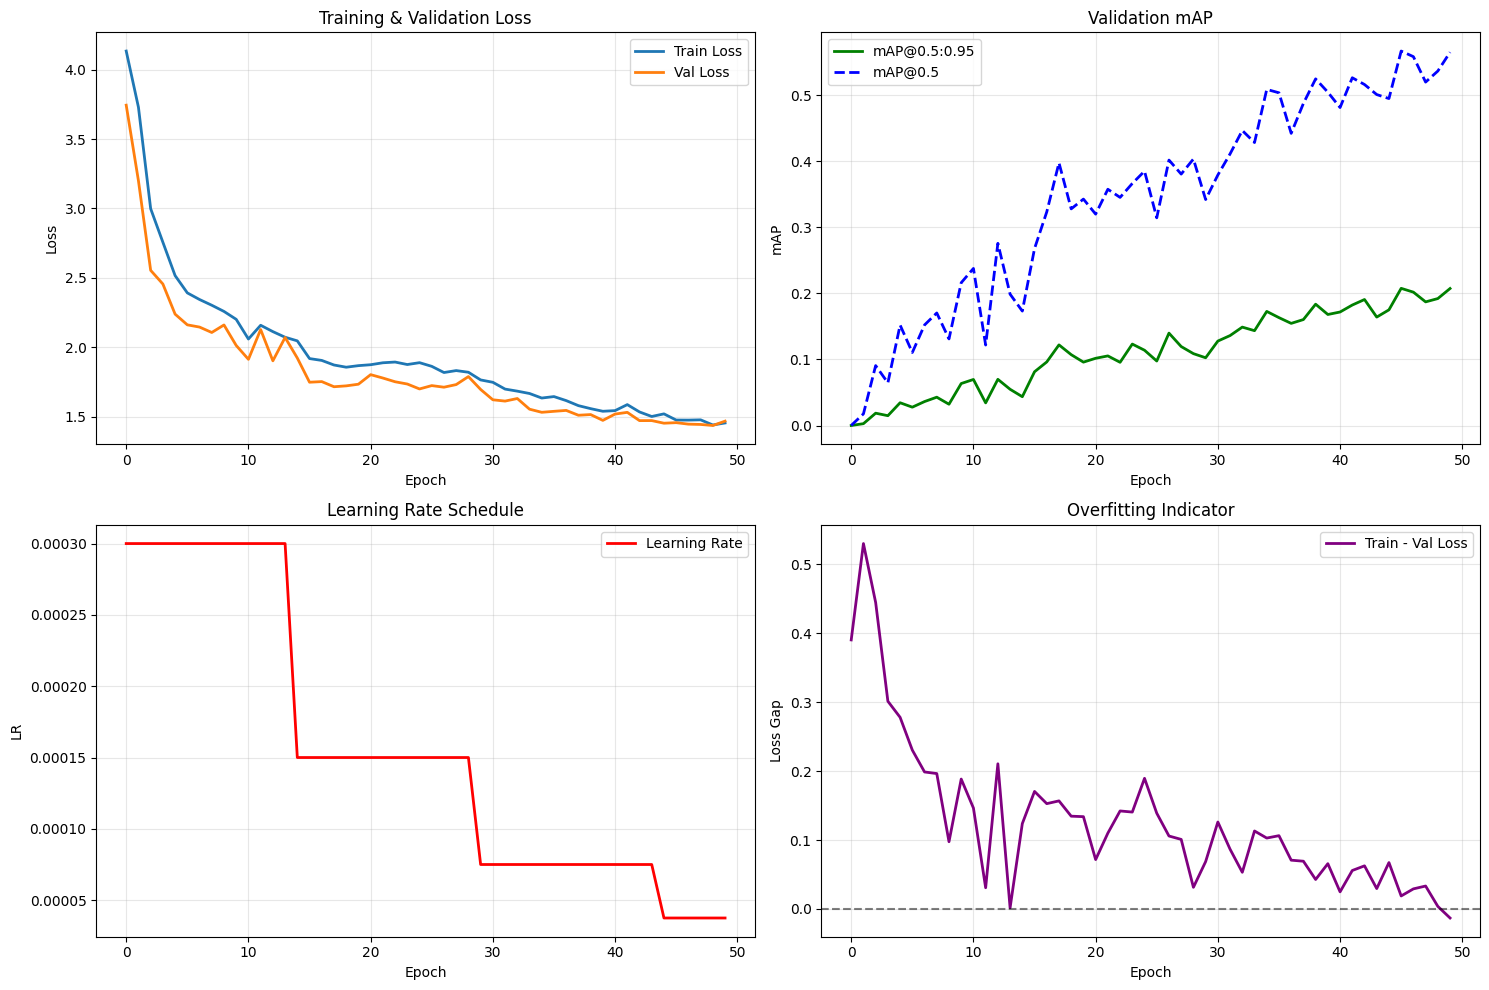

Графики отображены
🎉 Обучение завершено!


In [ ]:
history = trainer.fit()

In [ ]:
print(f"Лучший mAP@0.5: {max(trainer.history['val_map_50']):.4f}")
print(f"Эпоха с лучшим результатом: {np.argmax(trainer.history['val_map_50']) + 1}")

Лучший mAP@0.5: 0.5666
Эпоха с лучшим результатом: 46


In [ ]:
print(f"Лучший mAP@0.5:0.95: {max(trainer.history['val_map']):.4f}")
print(f"Эпоха с лучшим результатом: {np.argmax(trainer.history['val_map']) + 1}")

Лучший mAP@0.5:0.95: 0.2075
Эпоха с лучшим результатом: 46


**Итого я сумел добиться наилучшего результата с mAP 0.5 = 0.5666 и mAP 0.5:0.95 = 0.2075.**

P.S. при обучении, в качестве валидационного датасета использовался тестовый.

Ниже определена вспомогательная функция для валидации качества. Можете использовать `Runner.validate`. Важное уточнение, ей нужен метод для фильтрации предсказаний. Можете тоже скопировать его из семинара, если он у вас не менялся.

In [ ]:
from torchmetrics.detection import MeanAveragePrecision

@torch.no_grad()
def validate(dataloader, filter_predictions_func, box_format="xyxy", device="cpu", score_threshold=0.1, nms_threshold=0.5, **kwargs):
    """ Метод для валидации модели.
    Возвращает mAP (0.5 ... 0.95).
    """
    self.model.eval()
    # Считаем метрику mAP с помощью функции из torchmetrics
    metric = MeanAveragePrecision(box_format=box_format, iou_type="bbox")
    for images, targets in tqdm(dataloader, desc="Running validation", leave=False):
        images = images.to(device)
        outputs = self.model(images)
        predicts = filter_predictions_func(outputs, score_threshold, nms_threshold, **kwargs)
        metric.update(predicts, targets)
    return metric.compute()["map"].item()


**Как видно, в функции выше (которую нужно использовать для оценки по заданию) используется другой score_threshold, в отличие от моей функции в классе trainer. Поэтому пересчитаем метрику с score_threshold=0.1.**

In [ ]:
# Загружаем лучшую модель
trainer.load_checkpoint('/content/models/best.pth')

# Меняем порог уверенности
trainer.val_score_threshold = 0.1

# Вызываем evaluate_test (внутри использует _filter_predictions с nms_threshold=0.5)
test_metrics = trainer.evaluate_test()
print(f"mAP@0.5:0.95 (score=0.1, nms=0.5): {test_metrics['mAP@0.5:0.95']:.4f}")

📥 Чекпоинт загружен: /content/models/best.pth


[Test Evaluation]: 100%|██████████| 17/17 [00:04<00:00,  3.48it/s]


mAP@0.5:0.95 (score=0.1, nms=0.5): 0.2094
